<h1>Prompt Image Matching Process</h1>

In [1]:
import dill as pickle

with open('models/image_recommender_model_florence_long_word2vectfidf_files.pkl', 'rb') as f:
    system_image_recommender = pickle.load(f)
    sys_tagged_sample_df = pickle.load(f)
    text_preprocess = pickle.load(f)
    sys_X_emb = pickle.load(f)
    sys_text2emb = pickle.load(f)

In [2]:
from nltk.corpus import stopwords
import re
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity 

import gensim.downloader
# Show all available models in gensim-data
gensim_pretrains = list(gensim.downloader.info()['models'].keys())
word2vec_model = gensim.downloader.load(gensim_pretrains[3])

In [5]:
tagger = 'florence_long'
text_in = 'preparing for holidays'
output_df = system_image_recommender(sys_tagged_sample_df,tagger,[],sys_X_emb,text_in,
                                     sys_text2emb,thr_=0.0,top_n=10)
output_df

,file_name,florence_long,sim
401,e4fbca4dfddd44479bb252ff39ee6bcb.jpg,The image shows a group of golden Christmas or...,0.410169
16,db9fb33240fa4cf9a89889b75349df38.jpg,The image shows a family of four sitting on a ...,0.349119
313,ad064920300d439aa50b7e6ea16fc68c.jpg,"The image shows a family of three - a mother, ...",0.347394
339,d7254fcf1d094bc8a6befa7876850ec7.jpg,The image shows three red Christmas ornaments ...,0.342512
424,886d4c710db747849732c3762d087e8e.jpg,The image is a portrait of a young woman weari...,0.338351
1,5104d2b1073347a7acf5a7cc0d5e1d19.jpg,The image shows a young woman with long brown ...,0.331697
101,19b9732c8fb84fc99e3375cd2042129c.jpg,The image shows two men jumping in the air wit...,0.314080
276,41581b169b224de8b055cd1ca11f7e4f.jpg,The image is a landscape photograph of a beaut...,0.313430
332,2ca662b4e8f84eaa82837a5c5498795f.jpg,The image shows a young man wearing a blue shi...,0.309050
213,1972dec970f04e78af45bd408a013715.jpg,"In this image, we can see a young man standing...",0.306764


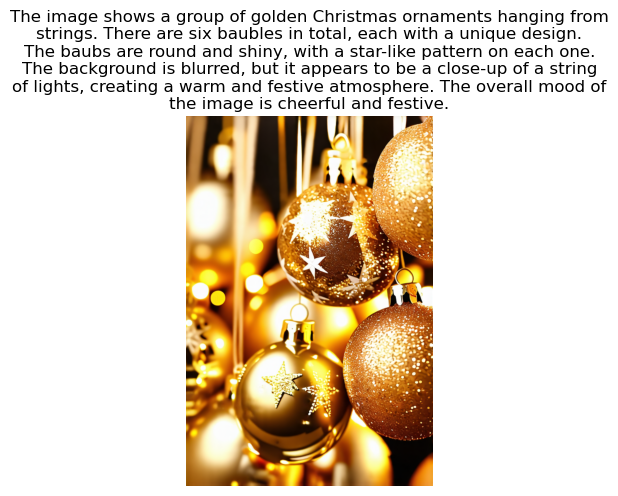

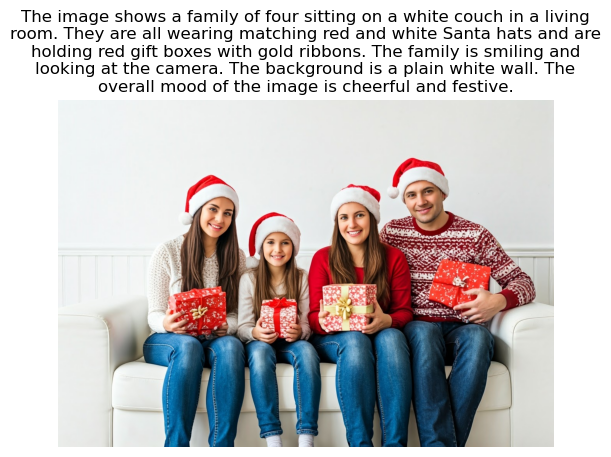

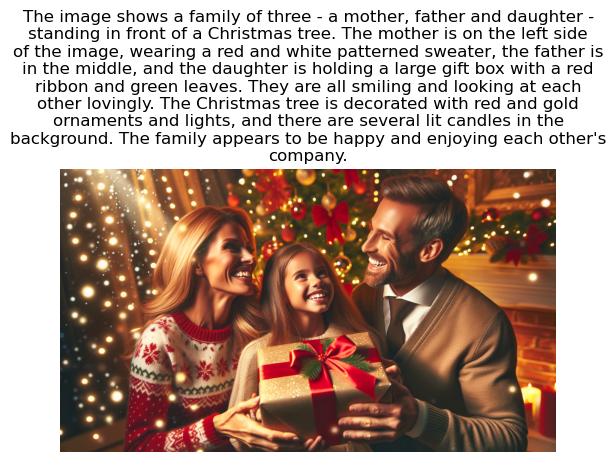

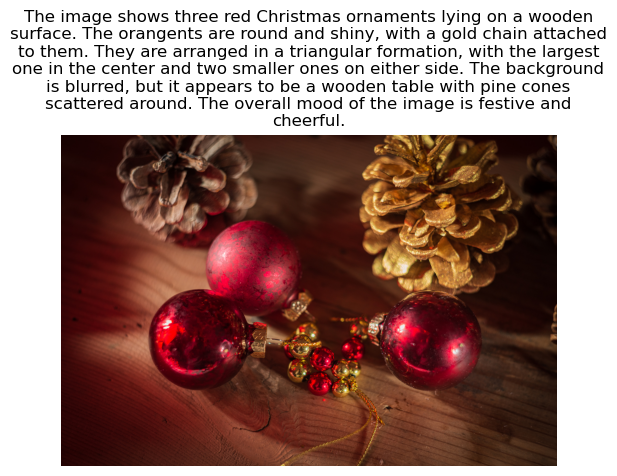

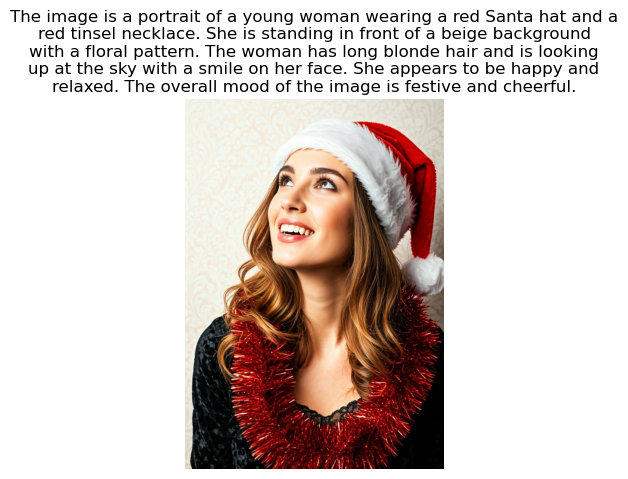

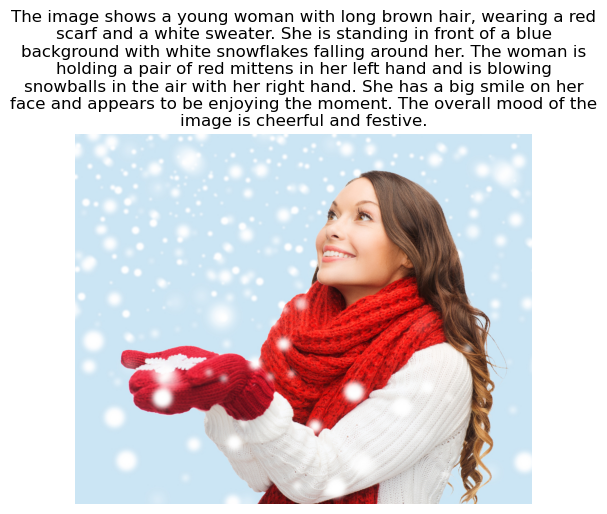

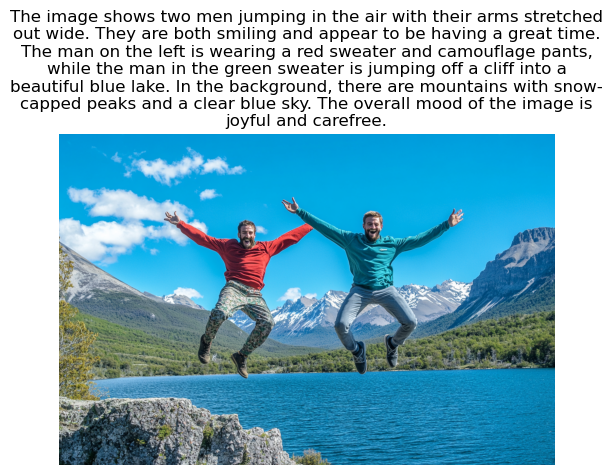

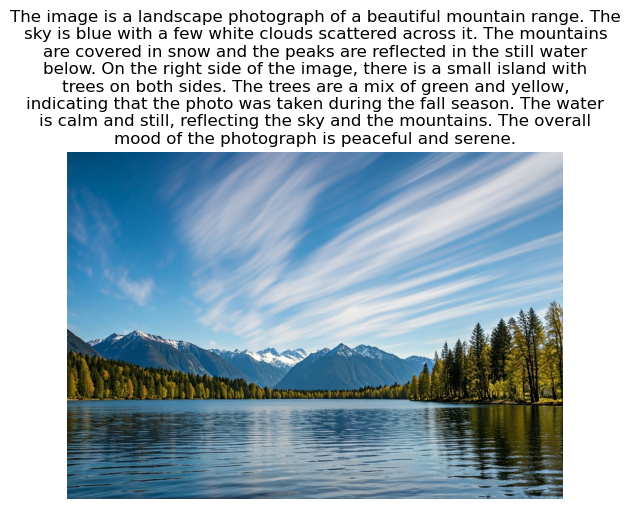

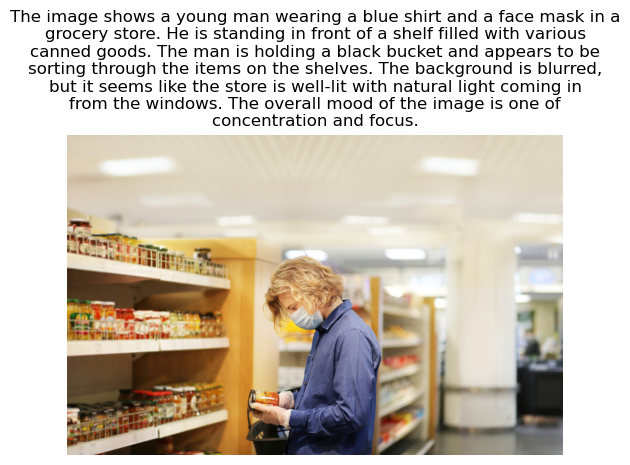

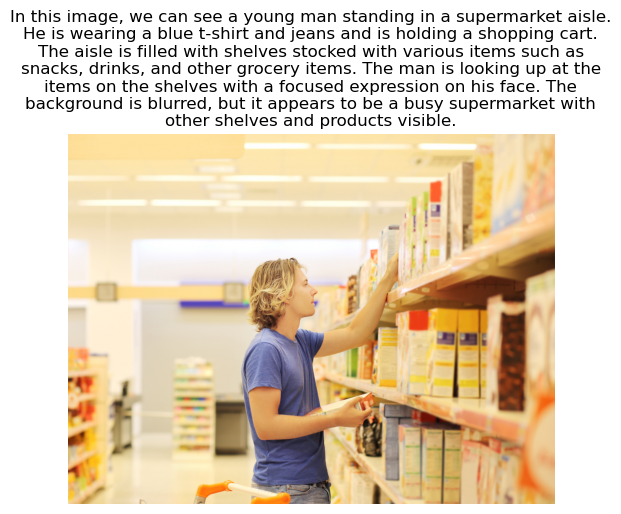

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

for i in range(len(output_df)):
    image_name = output_df.iloc[i].file_name
    image_tag =  output_df.iloc[i].florence_long
    image_filename = '../sample_imagesv2/'+image_name
    img = mpimg.imread(image_filename)
    plt.figure()
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_tag)
    plt.show()